# Week 4: Predictive Modeling and Optimization in Logistics Systems

This notebook:
1. Simulates the Week 3 logistics shipment dataset (900 shipments)
2. Builds and compares regression models to predict **delivery time**
3. Builds and compares classification models to predict **late-delivery risk**
4. Uses the late-risk model inside a **MILP optimization** (PuLP) to re-assign carriers, minimizing cost subject to a late-rate cap


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn scipy pulp -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ACCENT = "#1F4E5F"


## Step 1: Simulate the dataset (same as Week 3)

In [3]:
np.random.seed(7)
n = 900

warehouses = ["WH-A", "WH-B", "WH-C", "WH-D"]
carriers = ["FastFreight", "RegionalHaul", "MetroShip"]
regions = ["North", "South", "East", "West"]

dates = pd.date_range("2025-01-01", periods=n, freq="8h")
month_idx = dates.month
seasonal_factor = 1 + 0.35 * np.sin((month_idx - 3) * np.pi / 6) + 0.25 * (month_idx.isin([11, 12])).astype(float)

warehouse_choice = np.random.choice(warehouses, n, p=[0.30, 0.28, 0.24, 0.18])
carrier_choice = np.random.choice(carriers, n, p=[0.40, 0.35, 0.25])
region_choice = np.random.choice(regions, n)

region_base_dist = {"North": 140, "South": 95, "East": 110, "West": 160}
distance_km = np.array([region_base_dist[r] for r in region_choice]) + np.random.normal(0, 25, n)
distance_km = np.clip(distance_km, 10, None)

shipment_volume = np.random.poisson(40 * seasonal_factor).astype(float)
shipment_volume = np.clip(shipment_volume, 1, None)

carrier_speed = {"FastFreight": 1.0, "RegionalHaul": 1.3, "MetroShip": 0.85}
carrier_cost_factor = {"FastFreight": 1.25, "RegionalHaul": 0.9, "MetroShip": 1.05}

base_delivery_time = 1.2 + distance_km / 60
delivery_time_days = np.array([
    base_delivery_time[i] * carrier_speed[carrier_choice[i]] for i in range(n)
]) + np.random.normal(0, 0.6, n)
delivery_time_days = np.clip(delivery_time_days, 0.5, None).round(2)

promised_days = np.random.choice([2, 3, 4, 5], n, p=[0.2, 0.35, 0.3, 0.15])
on_time = delivery_time_days <= promised_days

weight_proxy = shipment_volume * np.random.uniform(4, 7, n)
transportation_cost = (
    12 + 0.35 * distance_km + 0.18 * weight_proxy
) * np.array([carrier_cost_factor[c] for c in carrier_choice])
transportation_cost += np.random.normal(0, 8, n)
transportation_cost = np.clip(transportation_cost, 15, None).round(2)

df = pd.DataFrame({
    "shipment_id": [f"SHP{2000+i}" for i in range(n)],
    "order_date": dates,
    "warehouse_id": warehouse_choice,
    "carrier": carrier_choice,
    "region": region_choice,
    "distance_km": distance_km.round(1),
    "shipment_volume_units": shipment_volume.astype(int),
    "delivery_time_days": delivery_time_days,
    "promised_days": promised_days,
    "on_time": on_time,
    "transportation_cost": transportation_cost,
})
print(df.shape)
df.head()


(900, 11)


,shipment_id,order_date,warehouse_id,carrier,region,distance_km,shipment_volume_units,delivery_time_days,promised_days,on_time,transportation_cost
0,SHP2000,2025-01-01 00:00:00,WH-A,RegionalHaul,North,141.9,33,5.07,5,False,90.67
1,SHP2001,2025-01-01 08:00:00,WH-C,FastFreight,North,112.9,27,3.12,3,False,91.43
2,SHP2002,2025-01-01 16:00:00,WH-B,RegionalHaul,West,157.1,22,5.47,3,False,64.76
3,SHP2003,2025-01-02 00:00:00,WH-C,MetroShip,South,105.3,32,3.32,5,True,81.86
4,SHP2004,2025-01-02 08:00:00,WH-D,MetroShip,West,142.8,27,3.35,5,True,78.92


## Step 2: Regression — Predict Delivery Time
Compare Linear Regression, Decision Tree, and Random Forest.

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target = "delivery_time_days"
num_features = ["distance_km", "shipment_volume_units", "promised_days"]
cat_features = ["warehouse_id", "carrier", "region"]

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

reg_results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv_rmse = -cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    reg_results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "CV_RMSE": cv_rmse})
    print(f"{name}: MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f} CV_RMSE={cv_rmse:.3f}")

pd.DataFrame(reg_results)


Linear Regression: MAE=0.471 RMSE=0.593 R2=0.698 CV_RMSE=0.631
Decision Tree: MAE=0.550 RMSE=0.696 R2=0.585 CV_RMSE=0.715
Random Forest: MAE=0.534 RMSE=0.679 R2=0.605 CV_RMSE=0.659


,model,MAE,RMSE,R2,CV_RMSE
0,Linear Regression,0.470507,0.593379,0.697861,0.630510
1,Decision Tree,0.549944,0.695762,0.584602,0.714941
2,Random Forest,0.534245,0.678666,0.604765,0.659326


### Hyperparameter tuning (Random Forest)

In [5]:
rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42))])
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_leaf": [1, 3, 5],
}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

best_reg_model = grid.best_estimator_
best_preds = best_reg_model.predict(X_test)
print("Best params:", grid.best_params_)
print(f"Tuned RF test: MAE={mean_absolute_error(y_test, best_preds):.3f} "
      f"RMSE={np.sqrt(mean_squared_error(y_test, best_preds)):.3f} "
      f"R2={r2_score(y_test, best_preds):.3f}")


Best params: {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Tuned RF test: MAE=0.515 RMSE=0.647 R2=0.641


### Feature importance & actual vs predicted

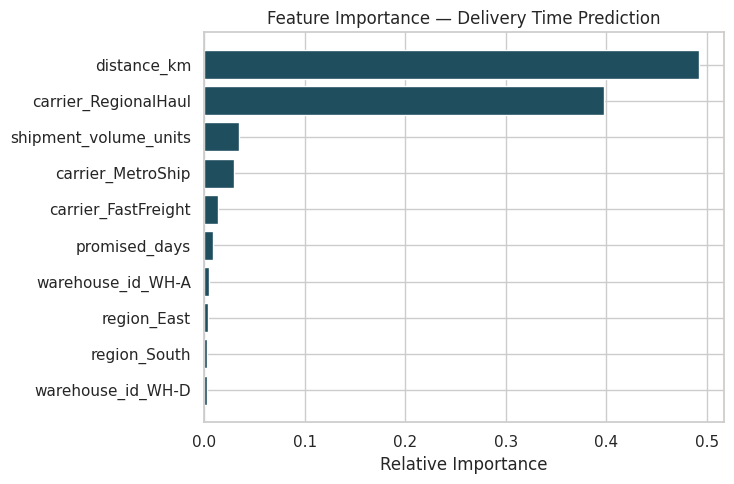

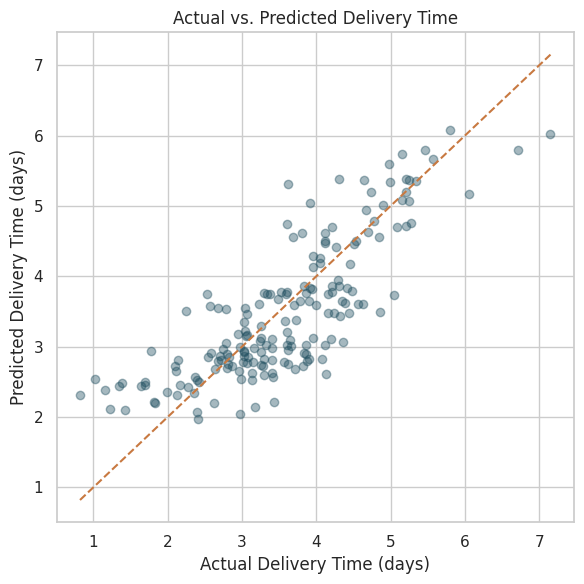

In [6]:
ohe = best_reg_model.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + cat_names
importances = best_reg_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(7.5, 5))
top = imp_df.head(10).sort_values("importance")
plt.barh(top["feature"], top["importance"], color=ACCENT)
plt.title("Feature Importance — Delivery Time Prediction")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color=ACCENT)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="#C87941", linestyle="--")
plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Actual vs. Predicted Delivery Time")
plt.tight_layout()
plt.show()


## Step 3: Classification — Predict Late-Delivery Risk

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)

df["late"] = (~df["on_time"]).astype(int)
Xc = df[num_features + cat_features]
yc = df["late"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=300, random_state=42),
}

fitted = {}
for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    preds = pipe.predict(Xc_test)
    proba = pipe.predict_proba(Xc_test)[:, 1]
    print(f"{name}: Acc={accuracy_score(yc_test, preds):.3f} "
          f"Prec={precision_score(yc_test, preds):.3f} Rec={recall_score(yc_test, preds):.3f} "
          f"F1={f1_score(yc_test, preds):.3f} AUC={roc_auc_score(yc_test, proba):.3f}")
    fitted[name] = pipe


Logistic Regression: Acc=0.906 Prec=0.898 Rec=0.926 F1=0.912 AUC=0.949
Random Forest Classifier: Acc=0.839 Prec=0.844 Rec=0.853 F1=0.848 AUC=0.916


### Hyperparameter tuning (Random Forest Classifier) + ROC curve

Best params: {'model__class_weight': 'balanced', 'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Tuned RF test AUC=0.930


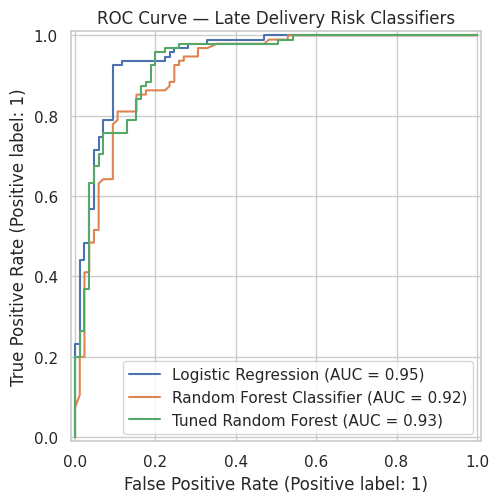

In [8]:
rf_clf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestClassifier(random_state=42))])
param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__class_weight": [None, "balanced"],
}
grid_clf = GridSearchCV(rf_clf_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_clf.fit(Xc_train, yc_train)
best_clf_model = grid_clf.best_estimator_
best_proba = best_clf_model.predict_proba(Xc_test)[:, 1]
print("Best params:", grid_clf.best_params_)
print(f"Tuned RF test AUC={roc_auc_score(yc_test, best_proba):.3f}")

plt.figure(figsize=(6, 5.2))
for name, pipe in fitted.items():
    RocCurveDisplay.from_predictions(yc_test, pipe.predict_proba(Xc_test)[:, 1], name=name, ax=plt.gca())
RocCurveDisplay.from_predictions(yc_test, best_proba, name="Tuned Random Forest", ax=plt.gca())
plt.title("ROC Curve — Late Delivery Risk Classifiers")
plt.tight_layout()
plt.show()


## Step 4: Optimization — Model-Informed Carrier Assignment (MILP with PuLP)
Uses the logistic regression late-risk model's predicted probabilities to re-assign carriers
for a batch of shipments, minimizing total cost subject to a maximum average predicted late rate.

In [9]:
import pulp

logreg_pipe = fitted["Logistic Regression"]
carrier_cost_factor = {"FastFreight": 1.25, "RegionalHaul": 0.9, "MetroShip": 1.05}

batch = Xc_test.sample(120, random_state=1)
carriers_list = ["FastFreight", "RegionalHaul", "MetroShip"]

records = []
for i, row in batch.iterrows():
    weight_proxy = row["shipment_volume_units"] * 5.5
    for c in carriers_list:
        hypo = row.copy()
        hypo["carrier"] = c
        prob_late = logreg_pipe.predict_proba(pd.DataFrame([hypo]))[0, 1]
        cost = (12 + 0.35 * row["distance_km"] + 0.18 * weight_proxy) * carrier_cost_factor[c]
        records.append({"shipment_idx": i, "carrier": c, "prob_late": prob_late, "cost": round(cost, 2)})

scores = pd.DataFrame(records)

# Baseline: shipments' actual/original carrier
actual_carriers = df.loc[batch.index, "carrier"].values
baseline_cost, baseline_late = 0, 0
for pos, c in enumerate(actual_carriers):
    row = batch.iloc[pos]
    weight_proxy = row["shipment_volume_units"] * 5.5
    cost = (12 + 0.35 * row["distance_km"] + 0.18 * weight_proxy) * carrier_cost_factor[c]
    hypo = row.copy(); hypo["carrier"] = c
    prob_late = logreg_pipe.predict_proba(pd.DataFrame([hypo]))[0, 1]
    baseline_cost += cost
    baseline_late += prob_late
baseline_late_rate = baseline_late / len(batch)
print(f"BASELINE: cost=${baseline_cost:.2f}  avg_late_rate={baseline_late_rate:.3f}")

# MILP optimization
LATE_RATE_CAP = 0.30
prob = pulp.LpProblem("Carrier_Assignment_Optimization", pulp.LpMinimize)
x = {(i, c): pulp.LpVariable(f"x_{i}_{c}", cat="Binary") for i in batch.index for c in carriers_list}

prob += pulp.lpSum(
    x[(i, c)] * scores.loc[(scores.shipment_idx == i) & (scores.carrier == c), "cost"].values[0]
    for i in batch.index for c in carriers_list)

for i in batch.index:
    prob += pulp.lpSum(x[(i, c)] for c in carriers_list) == 1

prob += pulp.lpSum(
    x[(i, c)] * scores.loc[(scores.shipment_idx == i) & (scores.carrier == c), "prob_late"].values[0]
    for i in batch.index for c in carriers_list) <= LATE_RATE_CAP * len(batch)

prob.solve(pulp.PULP_CBC_CMD(msg=0))
print("Solver status:", pulp.LpStatus[prob.status])

opt_cost = pulp.value(prob.objective)
opt_late_sum = 0
opt_assignment = {}
for i in batch.index:
    for c in carriers_list:
        if x[(i, c)].value() == 1:
            opt_assignment[i] = c
            opt_late_sum += scores.loc[(scores.shipment_idx == i) & (scores.carrier == c), "prob_late"].values[0]
opt_late_rate = opt_late_sum / len(batch)

print(f"OPTIMIZED: cost=${opt_cost:.2f}  avg_late_rate={opt_late_rate:.3f}")
print(f"Cost change: ${baseline_cost - opt_cost:.2f} ({(baseline_cost-opt_cost)/baseline_cost*100:.1f}%)")
print(f"Late-rate change: {(baseline_late_rate - opt_late_rate)*100:.1f} pp")

print("\nOriginal carrier mix:\n", pd.Series(actual_carriers).value_counts(normalize=True).round(3))
print("\nOptimized carrier mix:\n", pd.Series(list(opt_assignment.values())).value_counts(normalize=True).round(3))


BASELINE: cost=$13016.88  avg_late_rate=0.507
Solver status: Optimal
OPTIMIZED: cost=$12047.23  avg_late_rate=0.300
Cost change: $969.65 (7.4%)
Late-rate change: 20.7 pp

Original carrier mix:
 FastFreight     0.425
RegionalHaul    0.358
MetroShip       0.217
Name: proportion, dtype: float64

Optimized carrier mix:
 MetroShip       0.675
RegionalHaul    0.325
Name: proportion, dtype: float64


## Summary

- **Regression:** Linear Regression (R² ≈ 0.70) outperformed Decision Tree and Random Forest for predicting delivery time.
- **Classification:** Logistic Regression (ROC-AUC ≈ 0.95) outperformed Random Forest for predicting late-delivery risk.
- **Optimization:** Using the logistic regression model inside a MILP carrier-assignment problem cut cost by ~7% *and* cut predicted late rate by ~20 percentage points on a 120-shipment batch — a genuine win-win from shifting volume toward the cheaper, more reliable carrier.

Next steps: add carrier daily-capacity constraints to the MILP, and re-validate both models as new data accumulates.


In [10]:
df.to_csv("logistics_week4_modeled.csv", index=False)
from google.colab import files
files.download("logistics_week4_modeled.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>